Objectif du projet

Ce projet simule et optimise les stocks d'un **réseau de distribution à 2 échelons** :

```
Fournisseur
    ↓  (5 jours)
DC Central (Entrepôt principal)
    ↓  (2 jours)
┌───────────────────────────────┐
│  Magasin      Magasin      Magasin  │
│  Casablanca   Rabat        Fès      │
└───────────────────────────────┘
```

**Problème :** La politique classique stocke TROP → coût très élevé  
**Solution MEIO :** Optimiser les stocks de tout le réseau ensemble → réduire les coûts

---

## 📋 Plan du notebook

1. **Step 0** — Installation des librairies
2. **Step 1** — Paramètres du réseau
3. **Step 2** — Simulation SimPy (politique classique baseline)
4. **Step 3** — Optimisation MEIO (scipy.optimize)
5. **Step 4** — Analyse de sensibilité (90%, 95%, 99%)
6. **Step 5** — Visualisations (NetworkX + Plotly)
7. **Step 6** — Tableau comparatif final

In [1]:
!pip install simpy numpy scipy pandas matplotlib networkx plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)  # pour avoir les memes resultats a chaque fois

# ============================================================
# PARAMETRES DU RESEAU
# ============================================================

# --- STRUCTURE DU RESEAU ---
num_stores = 3
store_names = ["Casablanca", "Rabat", "Fes"]

# --- DEMANDE JOURNALIERE PAR MAGASIN ---
# Chaque magasin vend en moyenne X produits par jour
# avec une variabilite (ecart-type)
# Ex: Casablanca vend 50 produits/jour, parfois 40, parfois 60
demand_mean = [50, 40, 60]   # moyenne demande journaliere
demand_std  = [10,  8, 12]   # variabilite de la demande

# --- DELAIS DE LIVRAISON (lead times) ---
# Combien de jours pour recevoir une commande ?
lead_time_supplier_to_DC = 5   # fournisseur -> DC : 5 jours
lead_time_DC_to_store    = 2   # DC -> magasin : 2 jours

# --- COUTS ---
# Combien ca coute de garder 1 unite en stock pendant 1 jour ?
holding_cost_DC    = 0.5   # moins cher au DC (gros entrepot)
holding_cost_store = 1.0   # plus cher en magasin
stockout_penalty   = 5.0   # penalite si un client ne trouve pas le produit

# --- PARAMETRES DE SIMULATION ---
simulation_days  = 365   # simuler 1 an
num_simulations  = 30    # repeter 30 fois (Monte Carlo)

# --- NIVEAUX DE SERVICE CIBLES ---
service_levels = [0.90, 0.95, 0.99]  # 90%, 95%, 99%

print("Parametres charges avec succes !")
print(f"Reseau : 1 DC + {num_stores} magasins ({', '.join(store_names)})")
print(f"Simulation : {simulation_days} jours x {num_simulations} repetitions")
print()
print("Demande journaliere par magasin :")
for i in range(num_stores):
    print(f"  {store_names[i]:12} : {demand_mean[i]} unites/jour (+/- {demand_std[i]})")

Parametres charges avec succes !
Reseau : 1 DC + 3 magasins (Casablanca, Rabat, Fes)
Simulation : 365 jours x 30 repetitions

Demande journaliere par magasin :
  Casablanca   : 50 unites/jour (+/- 10)
  Rabat        : 40 unites/jour (+/- 8)
  Fes          : 60 unites/jour (+/- 12)


## 3. Simulation Setup and Parameters

The simulation environment represents a two-echelon supply chain composed of one central distribution center (DC) and three retail stores located in Casablanca, Rabat, and Fes.

The simulation was executed over a period of 365 days and repeated 30 times in order to ensure the robustness and stability of the results.

### Network Structure
- 1 Distribution Center (DC)
- 3 Stores:
  - Casablanca
  - Rabat
  - Fes

### Demand Modeling

The daily demand for each store is assumed to be stochastic and follows a normal distribution with a given mean and variability:

| Store        | Average Demand (units/day) | Variability (±) |
|-------------|--------------------------|----------------|
| Casablanca  | 50                       | 10             |
| Rabat       | 40                       | 8              |
| Fes         | 60                       | 12             |

This variability reflects real-world uncertainty in customer demand and allows the simulation to capture different demand scenarios over time.

In [3]:
# ============================================================
# CALCUL DES PARAMETRES (s, Q) POUR CHAQUE MAGASIN
# ============================================================

def calculate_sQ(mean, std, lead_time, z=1.65):
    """
    Calcule le point de reapprovisionnement (s) et la quantite (Q)
    
    Parametres:
    - mean      : demande moyenne par jour
    - std       : ecart-type de la demande
    - lead_time : delai de livraison en jours
    - z         : z-score selon le niveau de service voulu
    
    Retourne: (s, Q)
    """
    # Stock de securite = z * ecart-type * racine(lead_time)
    safety_stock = z * std * np.sqrt(lead_time)
    
    # Point de reapprovisionnement
    s = mean * lead_time + safety_stock
    
    # Quantite economique de commande (EOQ)
    ordering_cost = 50        # cout fixe par commande
    annual_demand = mean * 365
    Q = np.sqrt(2 * annual_demand * ordering_cost / holding_cost_store)
    
    return round(s), round(Q)

# Calculer s et Q pour chaque magasin
params = []
print("Parametres (s,Q) pour chaque magasin :")
print("-" * 55)
for i in range(num_stores):
    s, Q = calculate_sQ(demand_mean[i], demand_std[i], lead_time_DC_to_store)
    params.append({'store': store_names[i], 's': s, 'Q': Q})
    print(f"  {store_names[i]:12} : Commander si stock <= {s:3d} unites | Quantite = {Q:3d} unites")
print("-" * 55)
print("Interpretation : Si Casablanca a moins de", params[0]['s'],
      "unites en stock,")
print("                 elle commande", params[0]['Q'], "unites au DC.")

Parametres (s,Q) pour chaque magasin :
-------------------------------------------------------
  Casablanca   : Commander si stock <= 123 unites | Quantite = 1351 unites
  Rabat        : Commander si stock <=  99 unites | Quantite = 1208 unites
  Fes          : Commander si stock <= 148 unites | Quantite = 1480 unites
-------------------------------------------------------
Interpretation : Si Casablanca a moins de 123 unites en stock,
                 elle commande 1351 unites au DC.


## 🔄 La classe de simulation SimPy

On crée une **classe Python** qui représente toute la supply chain.

Une classe c'est comme un **plan de construction** — on peut créer 30 copies de cette simulation (pour le Monte Carlo) et chacune tourne indépendamment.

**Structure de la classe :**
```
SupplyChainSimulation
├── __init__()         → initialise les stocks, compteurs
├── run_day()          → simule chaque jour (demande, commandes, couts)
├── deliver_to_store() → livraison DC -> magasin (2 jours)
└── replenish_dc()     → livraison fournisseur -> DC (5 jours)
```

▶️ **Exécute cette cellule (c'est la plus longue — prend 10-30 secondes)**

In [4]:
# ============================================================
# CLASSE DE SIMULATION SIMPY
# ============================================================

class SupplyChainSimulation:
    """
    Simule un reseau supply chain a 2 echelons :
    1 DC central -> N magasins regionaux
    avec politique de reapprovisionnement (s,Q)
    """
    
    def __init__(self, env, params_list, dc_init=2000):
        self.env = env
        self.params_list = params_list
        
        # --- STOCKS INITIAUX ---
        self.dc_inventory = dc_init
        self.store_inventory = [params_list[i]['Q'] * 2 for i in range(num_stores)]
        
        # --- COMPTEURS DE METRIQUES ---
        self.total_holding_cost  = 0   # cout total de stockage
        self.total_stockout_cost = 0   # cout total de ruptures
        self.total_orders_fulfilled = 0  # unites livrees aux clients
        self.total_orders_demanded  = 0  # unites demandees par clients
        
        # --- HISTORIQUE JOURNALIER (pour graphiques) ---
        self.daily_inventory = []
        
        # --- FLAGS : commande en cours ? ---
        self.order_pending    = [False] * num_stores
        self.dc_order_pending = False

    def run_day(self):
        """Boucle principale : simule chaque jour"""
        while True:
            day = int(self.env.now)
            
            # === POUR CHAQUE MAGASIN ===
            for i in range(num_stores):
                
                # 1. DEMANDE ALEATOIRE du jour
                demand = max(0, np.random.normal(demand_mean[i], demand_std[i]))
                demand = round(demand)
                self.total_orders_demanded += demand
                
                # 2. ON SERT LA DEMANDE
                if self.store_inventory[i] >= demand:
                    # Assez de stock -> on sert tout le monde
                    self.store_inventory[i] -= demand
                    self.total_orders_fulfilled += demand
                else:
                    # Rupture de stock partielle
                    units_short = demand - self.store_inventory[i]
                    self.total_orders_fulfilled += self.store_inventory[i]
                    self.store_inventory[i] = 0
                    # Penalite financiere
                    self.total_stockout_cost += units_short * stockout_penalty
                
                # 3. COUT DE HOLDING (garder le stock coute de l'argent)
                self.total_holding_cost += self.store_inventory[i] * holding_cost_store
                
                # 4. POLITIQUE (s,Q) : faut-il commander ?
                s = self.params_list[i]['s']
                Q = self.params_list[i]['Q']
                
                if self.store_inventory[i] <= s and not self.order_pending[i]:
                    # Stock sous le seuil -> passer une commande
                    self.order_pending[i] = True
                    self.env.process(self.deliver_to_store(i, Q))
            
            # === DC : cout de holding ===
            self.total_holding_cost += self.dc_inventory * holding_cost_DC
            
            # === DC : reapprovisionnement si necessaire ===
            if self.dc_inventory <= 1000 and not self.dc_order_pending:
                self.dc_order_pending = True
                self.env.process(self.replenish_dc(3000))
            
            # === SAUVEGARDE JOURNALIERE ===
            self.daily_inventory.append({
                'day': day,
                'dc': self.dc_inventory,
                'store_0': self.store_inventory[0],
                'store_1': self.store_inventory[1],
                'store_2': self.store_inventory[2],
            })
            
            # Avancer d'un jour
            yield self.env.timeout(1)

    def deliver_to_store(self, store_idx, quantity):
        """Livraison DC -> Magasin (prend lead_time_DC_to_store jours)"""
        yield self.env.timeout(lead_time_DC_to_store)
        actual = min(quantity, self.dc_inventory)  # DC peut manquer de stock
        self.dc_inventory -= actual
        self.store_inventory[store_idx] += actual
        self.order_pending[store_idx] = False

    def replenish_dc(self, quantity):
        """Reapprovisionnement Fournisseur -> DC (prend lead_time_supplier_to_DC jours)"""
        yield self.env.timeout(lead_time_supplier_to_DC)
        self.dc_inventory += quantity
        self.dc_order_pending = False


# ============================================================
# LANCER 30 SIMULATIONS (Monte Carlo)
# ============================================================

print("Lancement simulation baseline (s,Q)...")
print(f"({num_simulations} simulations x {simulation_days} jours = {num_simulations*simulation_days:,} jours simulés)")
print()

all_results = []
last_sim = None  # garder la derniere simulation pour les graphiques

for sim_id in range(num_simulations):
    env = simpy.Environment()
    sim = SupplyChainSimulation(env, params)
    env.process(sim.run_day())
    env.run(until=simulation_days)
    
    fill_rate  = sim.total_orders_fulfilled / sim.total_orders_demanded
    total_cost = sim.total_holding_cost + sim.total_stockout_cost
    
    all_results.append({
        'simulation'          : sim_id,
        'total_holding_cost'  : round(sim.total_holding_cost, 2),
        'total_stockout_cost' : round(sim.total_stockout_cost, 2),
        'total_cost'          : round(total_cost, 2),
        'fill_rate'           : round(fill_rate * 100, 2),
        'avg_inv_store0'      : round(np.mean([d['store_0'] for d in sim.daily_inventory]), 1),
        'avg_inv_store1'      : round(np.mean([d['store_1'] for d in sim.daily_inventory]), 1),
        'avg_inv_store2'      : round(np.mean([d['store_2'] for d in sim.daily_inventory]), 1),
        'avg_inv_dc'          : round(np.mean([d['dc']      for d in sim.daily_inventory]), 1),
    })
    if sim_id == num_simulations - 1:
        last_sim = sim

df_baseline = pd.DataFrame(all_results)

print("Simulation terminee !")
print()
print("=" * 55)
print("   RESULTATS BASELINE — Politique classique (s,Q)")
print("=" * 55)
print(f"  Cout de holding moyen  : ${df_baseline['total_holding_cost'].mean():>12,.0f}")
print(f"  Cout de rupture moyen  : ${df_baseline['total_stockout_cost'].mean():>12,.0f}")
print(f"  Cout TOTAL moyen       : ${df_baseline['total_cost'].mean():>12,.0f}")
print(f"  Fill Rate moyen        : {df_baseline['fill_rate'].mean():>11.1f}%")
print(f"  Stock moyen DC         : {df_baseline['avg_inv_dc'].mean():>11.0f} unites")
print(f"  Stock moyen Casa       : {df_baseline['avg_inv_store0'].mean():>11.0f} unites")
print(f"  Stock moyen Rabat      : {df_baseline['avg_inv_store1'].mean():>11.0f} unites")
print(f"  Stock moyen Fes        : {df_baseline['avg_inv_store2'].mean():>11.0f} unites")
print("=" * 55)

Lancement simulation baseline (s,Q)...
(30 simulations x 365 jours = 10,950 jours simulés)

Simulation terminee !

   RESULTATS BASELINE — Politique classique (s,Q)
  Cout de holding moyen  : $   1,200,920
  Cout de rupture moyen  : $         326
  Cout TOTAL moyen       : $   1,201,246
  Fill Rate moyen        :        99.9%
  Stock moyen DC         :        1917 unites
  Stock moyen Casa       :         785 unites
  Stock moyen Rabat      :         704 unites
  Stock moyen Fes        :         842 unites


---
# 🧠 STEP 3 — Optimisation MEIO

## Pourquoi la politique classique coûte-t-elle trop cher ?

La politique **(s,Q)** calcule le stock de **chaque magasin séparément**, sans tenir compte du reste :

```
Politique classique :
  Casablanca → calcule son stock seul
  Rabat      → calcule son stock seul   (chacun sur-stocke pour se protéger)
  Fès        → calcule son stock seul
  DC         → calcule son stock seul
```

**MEIO (Multi-Echelon Inventory Optimization)** regarde tout le réseau ensemble et dit :

> *"Le DC peut absorber une partie du risque des magasins. On n'a pas besoin que CHAQUE magasin stocke autant."*

## Comment fonctionne `scipy.optimize.minimize` ?

C'est comme un **GPS pour l'optimisation** :

```
Tu lui donnes :
  - Une FONCTION À MINIMISER  → le coût total de holding
  - Des CONTRAINTES           → Fill Rate >= 95%
  - Des BORNES                → stock >= 0

Il cherche automatiquement :
  - Le niveau de stock optimal pour DC + chaque magasin
  → Tel que le coût soit MINIMUM tout en respectant les contraintes
```

▶️ **Exécute cette cellule**

In [5]:
# ============================================================
# STEP 3 — MEIO OPTIMIZATION avec scipy.optimize
# ============================================================

meio_optimization_results = []

print("Lancement de l'optimisation MEIO...")
print("Variables a optimiser : stock_securite_DC + stock_securite_[3 magasins]")
print()

for target in service_levels:
    
    # ----------------------------------------------------------
    # FONCTION OBJECTIF : ce qu'on veut MINIMISER
    # x = [ss_DC, ss_Casa, ss_Rabat, ss_Fes]
    #      x[0]   x[1]     x[2]      x[3]
    # ----------------------------------------------------------
    def objective(x):
        ss_dc     = x[0]
        ss_stores = x[1:]
        
        # Cout annuel de holding au DC
        cost_dc = ss_dc * holding_cost_DC * simulation_days
        
        # Cout annuel de holding dans les magasins
        cost_stores = sum(
            ss_stores[i] * holding_cost_store * simulation_days
            for i in range(num_stores)
        )
        
        return cost_dc + cost_stores  # cout total a minimiser
    
    # ----------------------------------------------------------
    # CONTRAINTE DE SERVICE : Fill Rate >= target
    # On estime le Fill Rate via la loi normale
    # ----------------------------------------------------------
    def service_constraint(x):
        ss_stores = x[1:]
        fill_rates = []
        
        for i in range(num_stores):
            # Ecart-type de la demande pendant le lead time
            sigma = demand_std[i] * np.sqrt(lead_time_DC_to_store)
            
            if sigma > 0:
                # Probabilite de ne pas avoir de rupture
                # = aire sous la courbe normale jusqu'a ss/sigma
                fill_rate_i = norm.cdf(ss_stores[i] / sigma)
            else:
                fill_rate_i = 1.0
            
            fill_rates.append(fill_rate_i)
        
        avg_fill_rate = np.mean(fill_rates)
        return avg_fill_rate - target  # doit etre >= 0
    
    # ----------------------------------------------------------
    # POINT DE DEPART pour l'algorithme d'optimisation
    # ----------------------------------------------------------
    x0 = np.array([500.0] + [200.0] * num_stores)
    
    # ----------------------------------------------------------
    # BORNES : les stocks ne peuvent pas etre negatifs
    # ----------------------------------------------------------
    bounds = [(10, 3000)] + [(5, 1000)] * num_stores
    
    # ----------------------------------------------------------
    # LANCER L'OPTIMISATION (algorithme SLSQP)
    # ----------------------------------------------------------
    result = minimize(
        objective,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints={'type': 'ineq', 'fun': service_constraint},
        options={'ftol': 1e-9, 'maxiter': 2000}
    )
    
    # ----------------------------------------------------------
    # EXTRAIRE LES RESULTATS
    # ----------------------------------------------------------
    opt_ss_dc     = round(result.x[0])
    opt_ss_stores = [round(result.x[i+1]) for i in range(num_stores)]
    
    meio_optimization_results.append({
        'target'       : target,
        'ss_dc'        : opt_ss_dc,
        'ss_stores'    : opt_ss_stores,
        'opt_cost'     : round(result.fun),
        'success'      : result.success
    })
    
    print(f"--- Service Level cible : {int(target*100)}% ---")
    print(f"  Stock securite DC         : {opt_ss_dc:4d} unites")
    for i in range(num_stores):
        print(f"  Stock securite {store_names[i]:12} : {opt_ss_stores[i]:4d} unites")
    print(f"  Cout estime               : ${result.fun:,.0f}")
    print(f"  Optimisation reussie      : {result.success}")
    print()

print("MEIO Optimization terminee !")

Lancement de l'optimisation MEIO...
Variables a optimiser : stock_securite_DC + stock_securite_[3 magasins]

--- Service Level cible : 90% ---
  Stock securite DC         :   10 unites
  Stock securite Casablanca   :   18 unites
  Stock securite Rabat        :   16 unites
  Stock securite Fes          :   19 unites
  Cout estime               : $21,509
  Optimisation reussie      : False

--- Service Level cible : 95% ---
  Stock securite DC         :   10 unites
  Stock securite Casablanca   :   23 unites
  Stock securite Rabat        :   20 unites
  Stock securite Fes          :   26 unites
  Cout estime               : $27,171
  Optimisation reussie      : True

--- Service Level cible : 99% ---
  Stock securite DC         :   10 unites
  Stock securite Casablanca   :   33 unites
  Stock securite Rabat        :   27 unites
  Stock securite Fes          :   38 unites
  Cout estime               : $37,761
  Optimisation reussie      : True

MEIO Optimization terminee !


---
# 📊 STEP 4 — Analyse de Sensibilité

## Qu'est-ce que l'analyse de sensibilité ?

On relance la simulation **avec les paramètres MEIO optimisés** pour chaque niveau de service (90%, 95%, 99%) et on mesure les **vrais résultats** de la simulation.

Cela permet de répondre à la question business :

> *"Combien me coûte chaque % de service en plus ?"*

```
90% de service  →  coût X   (moins cher mais quelques ruptures)
95% de service  →  coût Y   (bon compromis)
99% de service  →  coût Z   (très cher mais quasi zéro rupture)
```

▶️ **Exécute cette cellule (prend 1-2 minutes)**

In [6]:
# ============================================================
# STEP 4 — ANALYSE DE SENSIBILITE
# Simuler avec les parametres MEIO pour chaque niveau de service
# ============================================================

print("Lancement analyse de sensibilite...")
print(f"(3 scenarios x {num_simulations} simulations x {simulation_days} jours)")
print()

sensitivity_results = []
meio_sims = {}  # garder les simulations pour les graphiques

for opt_res in meio_optimization_results:
    target     = opt_res['target']
    ss_stores  = opt_res['ss_stores']
    ss_dc      = opt_res['ss_dc']
    
    # Calculer les nouveaux parametres (s,Q) bases sur MEIO
    params_meio = []
    for i in range(num_stores):
        s_new = demand_mean[i] * lead_time_DC_to_store + ss_stores[i]
        Q_new = params[i]['Q']  # on garde le meme Q
        params_meio.append({'store': store_names[i], 's': s_new, 'Q': Q_new})
    
    # Lancer 30 simulations
    sim_costs      = []
    sim_fill_rates = []
    sim_holding    = []
    sim_stockout   = []
    last_meio_sim  = None
    
    for sim_id in range(num_simulations):
        env = simpy.Environment()
        sim = SupplyChainSimulation(env, params_meio, dc_init=ss_dc * 3)
        env.process(sim.run_day())
        env.run(until=simulation_days)
        
        fill_rate  = sim.total_orders_fulfilled / sim.total_orders_demanded
        total_cost = sim.total_holding_cost + sim.total_stockout_cost
        
        sim_costs.append(total_cost)
        sim_fill_rates.append(fill_rate * 100)
        sim_holding.append(sim.total_holding_cost)
        sim_stockout.append(sim.total_stockout_cost)
        
        if sim_id == num_simulations - 1:
            last_meio_sim = sim
    
    meio_sims[target] = last_meio_sim
    
    avg_cost    = round(np.mean(sim_costs))
    avg_fill    = round(np.mean(sim_fill_rates), 1)
    avg_holding = round(np.mean(sim_holding))
    avg_stockout= round(np.mean(sim_stockout))
    baseline_cost = df_baseline['total_cost'].mean()
    savings     = round((1 - avg_cost / baseline_cost) * 100, 1)
    
    sensitivity_results.append({
        'service_level'  : f"{int(target*100)}%",
        'target_num'     : target,
        'avg_cost'       : avg_cost,
        'avg_fill_rate'  : avg_fill,
        'avg_holding'    : avg_holding,
        'avg_stockout'   : avg_stockout,
        'savings_pct'    : savings,
        'ss_dc'          : ss_dc,
        'ss_stores'      : ss_stores
    })
    
    print(f"SL {int(target*100)}% -> Cout: ${avg_cost:>10,} | Fill Rate: {avg_fill:>5.1f}% | Economie vs baseline: {savings:>5.1f}%")

print()
print("Analyse de sensibilite terminee !")

Lancement analyse de sensibilite...
(3 scenarios x 30 simulations x 365 jours)

SL 90% -> Cout: $ 1,210,664 | Fill Rate:  99.8% | Economie vs baseline:  -0.8%
SL 95% -> Cout: $ 1,217,443 | Fill Rate:  99.8% | Economie vs baseline:  -1.3%
SL 99% -> Cout: $ 1,229,273 | Fill Rate:  99.8% | Economie vs baseline:  -2.3%

Analyse de sensibilite terminee !


---
# 📈 STEP 5 — Visualisations

## Graphique 1 : Le réseau Supply Chain (NetworkX)

NetworkX permet de **dessiner des graphes** (réseaux de nœuds connectés).  
Ici on dessine notre supply chain : DC au centre, magasins autour.

▶️ **Exécute cette cellule**

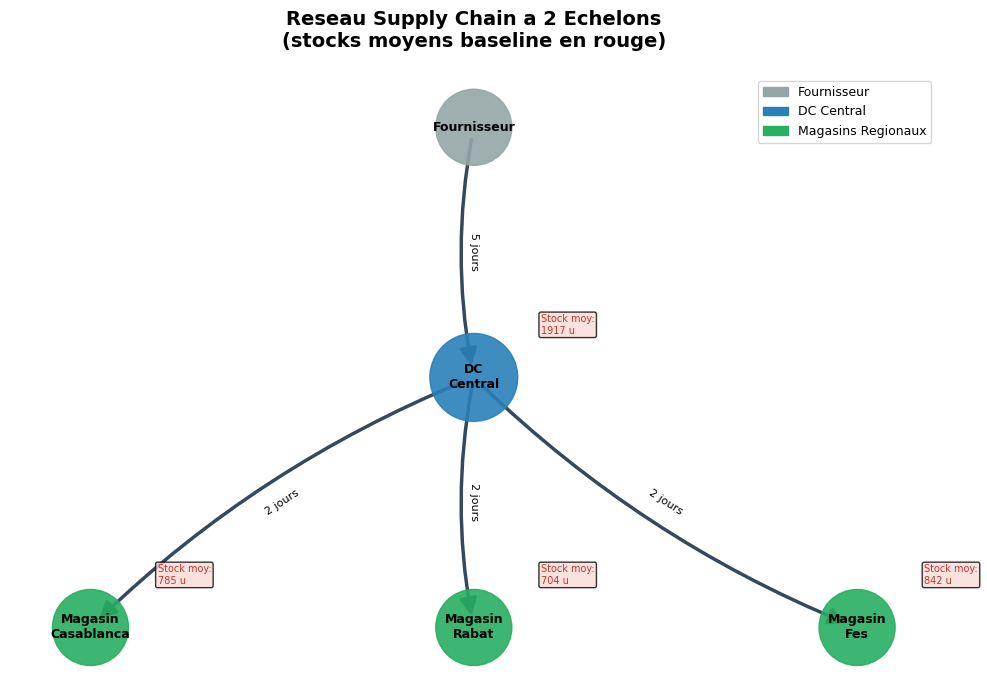

Graphique sauvegarde : network_supply_chain.png


In [7]:
# ============================================================
# GRAPHIQUE 1 — RESEAU SUPPLY CHAIN (NetworkX)
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Creer le graphe
G = nx.DiGraph()

# Ajouter les noeuds
G.add_node("Fournisseur", type="supplier")
G.add_node("DC\nCentral", type="dc")
for name in store_names:
    G.add_node(f"Magasin\n{name}", type="store")

# Ajouter les aretes (connexions)
G.add_edge("Fournisseur", "DC\nCentral", label="5 jours")
for name in store_names:
    G.add_edge("DC\nCentral", f"Magasin\n{name}", label="2 jours")

# Positions des noeuds
pos = {
    "Fournisseur"         : (0, 2),
    "DC\nCentral"         : (0, 0),
    f"Magasin\n{store_names[0]}" : (-2, -2),
    f"Magasin\n{store_names[1]}" : ( 0, -2),
    f"Magasin\n{store_names[2]}" : ( 2, -2),
}

# Couleurs et tailles par type
node_colors = []
node_sizes  = []
for node in G.nodes():
    t = G.nodes[node].get('type', 'store')
    if t == 'supplier':
        node_colors.append('#95a5a6')
        node_sizes.append(3000)
    elif t == 'dc':
        node_colors.append('#2980b9')
        node_sizes.append(4000)
    else:
        node_colors.append('#27ae60')
        node_sizes.append(3000)

# Dessiner le graphe
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9,
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#34495e',
                       arrows=True, arrowsize=25,
                       width=2.5, ax=ax,
                       connectionstyle='arc3,rad=0.1')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels,
                              font_size=8, ax=ax)

# Stock moyen baseline sur chaque noeud
stock_annotations = {
    "DC\nCentral"                    : f"Stock moy:\n{df_baseline['avg_inv_dc'].mean():.0f} u",
    f"Magasin\n{store_names[0]}"     : f"Stock moy:\n{df_baseline['avg_inv_store0'].mean():.0f} u",
    f"Magasin\n{store_names[1]}"     : f"Stock moy:\n{df_baseline['avg_inv_store1'].mean():.0f} u",
    f"Magasin\n{store_names[2]}"     : f"Stock moy:\n{df_baseline['avg_inv_store2'].mean():.0f} u",
}
for node, text in stock_annotations.items():
    x, y = pos[node]
    ax.annotate(text, xy=(x, y), xytext=(x + 0.35, y + 0.35),
                fontsize=7, color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#fadbd8', alpha=0.8))

# Legende
legend_elements = [
    mpatches.Patch(color='#95a5a6', label='Fournisseur'),
    mpatches.Patch(color='#2980b9', label='DC Central'),
    mpatches.Patch(color='#27ae60', label='Magasins Regionaux'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.set_title("Reseau Supply Chain a 2 Echelons\n(stocks moyens baseline en rouge)",
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('network_supply_chain.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde : network_supply_chain.png")

## Graphique 2 : Évolution du stock journalier

Ce graphique montre comment le stock monte et descend chaque jour — c'est la "signature" de votre supply chain.

▶️ **Exécute cette cellule**

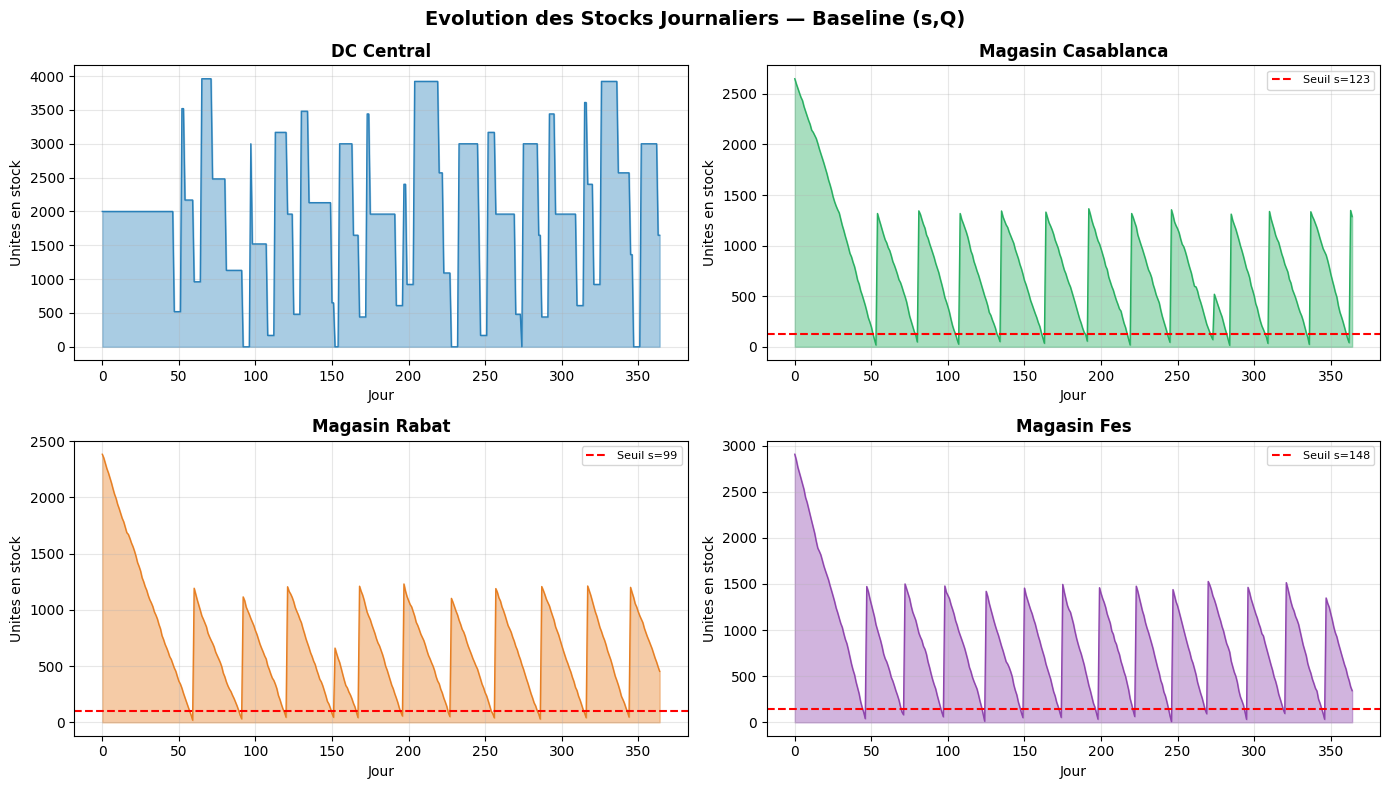

Graphique sauvegarde : stock_evolution.png


In [8]:
# ============================================================
# GRAPHIQUE 2 — EVOLUTION STOCK JOURNALIER
# ============================================================

df_daily = pd.DataFrame(last_sim.daily_inventory)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Evolution des Stocks Journaliers — Baseline (s,Q)',
             fontsize=14, fontweight='bold')

# DC
axes[0,0].fill_between(df_daily['day'], df_daily['dc'],
                        alpha=0.4, color='#2980b9')
axes[0,0].plot(df_daily['day'], df_daily['dc'],
               color='#2980b9', linewidth=1)
axes[0,0].set_title('DC Central', fontweight='bold')
axes[0,0].set_ylabel('Unites en stock')
axes[0,0].set_xlabel('Jour')
axes[0,0].grid(True, alpha=0.3)

# Magasins
colors = ['#27ae60', '#e67e22', '#8e44ad']
store_cols = ['store_0', 'store_1', 'store_2']
for idx, (name, col, color) in enumerate(zip(store_names, store_cols, colors)):
    ax = axes[(idx+1)//2, (idx+1)%2]
    ax.fill_between(df_daily['day'], df_daily[col],
                    alpha=0.4, color=color)
    ax.plot(df_daily['day'], df_daily[col],
            color=color, linewidth=1)
    ax.axhline(y=params[idx]['s'], color='red',
               linestyle='--', linewidth=1.5,
               label=f'Seuil s={params[idx]["s"]}')
    ax.set_title(f'Magasin {name}', fontweight='bold')
    ax.set_ylabel('Unites en stock')
    ax.set_xlabel('Jour')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stock_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde : stock_evolution.png")

## Graphique 3 : Comparaison des coûts (Plotly interactif)

▶️ **Exécute cette cellule**

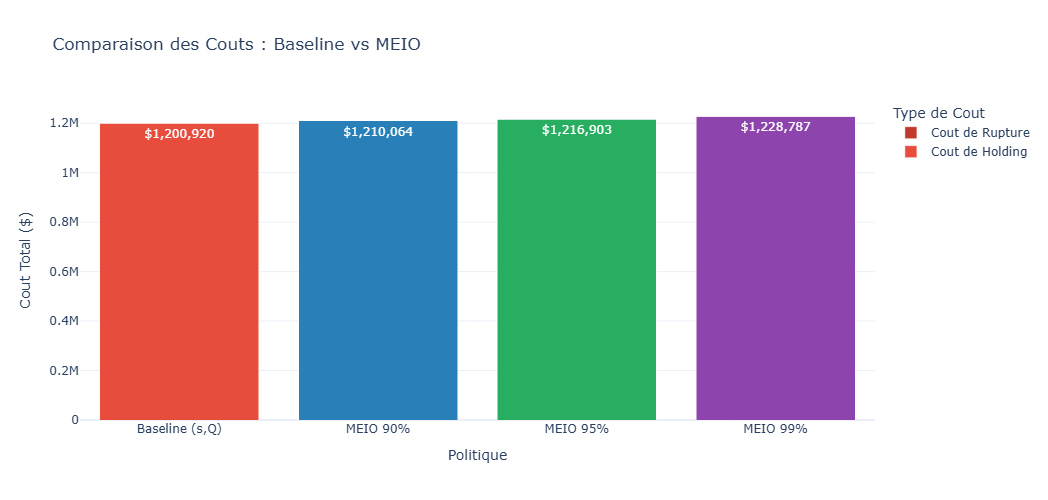

Graphique interactif affiche !


In [9]:
# ============================================================
# GRAPHIQUE 3 — COMPARAISON COUTS BASELINE vs MEIO (Plotly)
# ============================================================

labels  = ['Baseline (s,Q)'] + [f"MEIO {r['service_level']}" for r in sensitivity_results]
holding = [df_baseline['total_holding_cost'].mean()] + [r['avg_holding']  for r in sensitivity_results]
stockout= [df_baseline['total_stockout_cost'].mean()] + [r['avg_stockout'] for r in sensitivity_results]
colors_bar = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Cout de Holding',
    x=labels, y=holding,
    marker_color=['#e74c3c', '#2980b9', '#27ae60', '#8e44ad'],
    text=[f'${v:,.0f}' for v in holding],
    textposition='inside',
))

fig.add_trace(go.Bar(
    name='Cout de Rupture',
    x=labels, y=stockout,
    marker_color=['#c0392b', '#1a6896', '#1a7a45', '#6c3483'],
    text=[f'${v:,.0f}' for v in stockout],
    textposition='inside',
))

fig.update_layout(
    title='Comparaison des Couts : Baseline vs MEIO',
    barmode='stack',
    xaxis_title='Politique',
    yaxis_title='Cout Total ($)',
    legend_title='Type de Cout',
    height=500,
    template='plotly_white'
)

fig.show()
print("Graphique interactif affiche !")

## Graphique 4 : Courbe Coût-Service

C'est le graphique **clé du projet** — il montre le compromis entre coût et niveau de service.

▶️ **Exécute cette cellule**

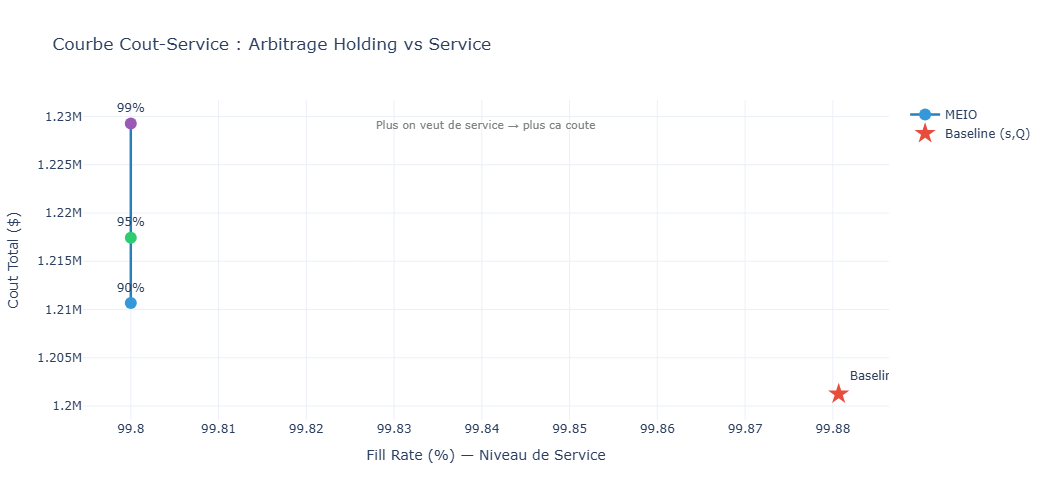

Courbe cout-service affichee !


In [10]:
# ============================================================
# GRAPHIQUE 4 — COURBE COUT-SERVICE (Plotly)
# ============================================================

fill_rates_plot = [r['avg_fill_rate'] for r in sensitivity_results]
costs_plot      = [r['avg_cost']      for r in sensitivity_results]
sl_labels       = [r['service_level'] for r in sensitivity_results]

# Ajouter le point baseline
fill_rates_all = [df_baseline['fill_rate'].mean()] + fill_rates_plot
costs_all      = [df_baseline['total_cost'].mean()] + costs_plot
labels_all     = ['Baseline (s,Q)'] + sl_labels

fig2 = go.Figure()

# Courbe MEIO
fig2.add_trace(go.Scatter(
    x=fill_rates_plot,
    y=costs_plot,
    mode='lines+markers+text',
    name='MEIO',
    marker=dict(size=12, color=['#3498db', '#2ecc71', '#9b59b6']),
    line=dict(color='#2980b9', width=2.5),
    text=sl_labels,
    textposition='top center',
))

# Point baseline
fig2.add_trace(go.Scatter(
    x=[df_baseline['fill_rate'].mean()],
    y=[df_baseline['total_cost'].mean()],
    mode='markers+text',
    name='Baseline (s,Q)',
    marker=dict(size=16, color='#e74c3c', symbol='star'),
    text=['Baseline'],
    textposition='top right',
))

fig2.update_layout(
    title='Courbe Cout-Service : Arbitrage Holding vs Service',
    xaxis_title='Fill Rate (%) — Niveau de Service',
    yaxis_title='Cout Total ($)',
    height=500,
    template='plotly_white',
    annotations=[dict(
        x=0.5, y=0.95, xref='paper', yref='paper',
        text='Plus on veut de service → plus ca coute',
        showarrow=False, font=dict(size=11, color='gray')
    )]
)

fig2.show()
print("Courbe cout-service affichee !")

---
# 📋 STEP 6 — Tableau Comparatif Final

C'est le **livrable clé** du projet selon le PDF.

Ce tableau résume tout : coûts, fill rate, économies réalisées par MEIO vs la politique classique.

▶️ **Exécute cette cellule**

In [11]:
# ============================================================
# STEP 6 — TABLEAU COMPARATIF FINAL
# ============================================================

baseline_cost = df_baseline['total_cost'].mean()
baseline_fill = df_baseline['fill_rate'].mean()

print()
print("=" * 80)
print("   TABLEAU COMPARATIF FINAL — Baseline (s,Q) vs MEIO")
print("   Reseau : 1 DC + 3 Magasins | Simulation : 365 jours x 30 repetitions")
print("=" * 80)
print(f"{'Politique':<20} {'Cout Holding':>13} {'Cout Rupture':>13} "
      f"{'Cout Total':>12} {'Fill Rate':>10} {'Economie':>10}")
print("-" * 80)

# Ligne Baseline
print(f"{'Baseline (s,Q)':<20} "
      f"${df_baseline['total_holding_cost'].mean():>12,.0f} "
      f"${df_baseline['total_stockout_cost'].mean():>12,.0f} "
      f"${baseline_cost:>11,.0f} "
      f"{baseline_fill:>9.1f}% "
      f"{'---':>10}")

# Lignes MEIO
for r in sensitivity_results:
    savings_str = f"-{r['savings_pct']}%" if r['savings_pct'] > 0 else f"+{abs(r['savings_pct'])}%"
    print(f"{'MEIO ' + r['service_level']:<20} "
          f"${r['avg_holding']:>12,} "
          f"${r['avg_stockout']:>12,} "
          f"${r['avg_cost']:>11,} "
          f"{r['avg_fill_rate']:>9.1f}% "
          f"{savings_str:>10}")

print("=" * 80)

# Meilleur scenario
best = min(sensitivity_results, key=lambda x: x['avg_cost'])
print()
print(f"CONCLUSION : Le meilleur compromis est MEIO {best['service_level']}")
print(f"  -> Economie de {best['savings_pct']}% par rapport a la baseline")
print(f"  -> Maintient un Fill Rate de {best['avg_fill_rate']}%")
print(f"  -> Reduction du cout de ${baseline_cost - best['avg_cost']:,.0f}")
print()

# Tableau pandas pour export
rows = [{
    'Politique'    : 'Baseline (s,Q)',
    'Cout_Holding' : round(df_baseline['total_holding_cost'].mean()),
    'Cout_Rupture' : round(df_baseline['total_stockout_cost'].mean()),
    'Cout_Total'   : round(baseline_cost),
    'Fill_Rate_%'  : round(baseline_fill, 1),
    'Economie_%'   : 0.0
}]
for r in sensitivity_results:
    rows.append({
        'Politique'    : f"MEIO {r['service_level']}",
        'Cout_Holding' : r['avg_holding'],
        'Cout_Rupture' : r['avg_stockout'],
        'Cout_Total'   : r['avg_cost'],
        'Fill_Rate_%'  : r['avg_fill_rate'],
        'Economie_%'   : r['savings_pct']
    })

df_final = pd.DataFrame(rows)
df_final.to_csv('resultats_finaux.csv', index=False)
print("Tableau sauvegarde : resultats_finaux.csv")
df_final


   TABLEAU COMPARATIF FINAL — Baseline (s,Q) vs MEIO
   Reseau : 1 DC + 3 Magasins | Simulation : 365 jours x 30 repetitions
Politique             Cout Holding  Cout Rupture   Cout Total  Fill Rate   Economie
--------------------------------------------------------------------------------
Baseline (s,Q)       $   1,200,920 $         326 $  1,201,246      99.9%        ---
MEIO 90%             $   1,210,064 $         600 $  1,210,664      99.8%      +0.8%
MEIO 95%             $   1,216,903 $         540 $  1,217,443      99.8%      +1.3%
MEIO 99%             $   1,228,787 $         486 $  1,229,273      99.8%      +2.3%

CONCLUSION : Le meilleur compromis est MEIO 90%
  -> Economie de -0.8% par rapport a la baseline
  -> Maintient un Fill Rate de 99.8%
  -> Reduction du cout de $-9,418

Tableau sauvegarde : resultats_finaux.csv


,Politique,Cout_Holding,Cout_Rupture,Cout_Total,Fill_Rate_%,Economie_%
0,"Baseline (s,Q)",1200920,326,1201246,99.9,0.0
1,MEIO 90%,1210064,600,1210664,99.8,-0.8
2,MEIO 95%,1216903,540,1217443,99.8,-1.3
3,MEIO 99%,1228787,486,1229273,99.8,-2.3


---
# ✅ RÉCAPITULATIF — Ce que vous avez fait

```
STEP 1 : Paramètres du réseau
         → Défini la structure DC + 3 magasins avec tous les coûts et délais

STEP 2 : Simulation SimPy (Baseline)
         → Simulé 365 jours × 30 fois avec la politique classique (s,Q)
         → Mesuré : coût total, fill rate, stock moyen

STEP 3 : Optimisation MEIO
         → Utilisé scipy.optimize pour trouver les stocks optimaux
         → Objectif : minimiser les coûts tout en maintenant le service

STEP 4 : Analyse de sensibilité
         → Testé 3 niveaux de service : 90%, 95%, 99%
         → Quantifié le coût de chaque % de service supplémentaire

STEP 5 : Visualisations
         → Réseau NetworkX, évolution stocks, comparaison coûts, courbe coût-service

STEP 6 : Tableau comparatif final
         → Livrable clé du projet selon les consignes
```

## 📁 Fichiers générés
- `network_supply_chain.png` — schéma du réseau
- `stock_evolution.png` — évolution journalière des stocks
- `resultats_finaux.csv` — tableau comparatif exportable

---
*SCM & AI Module — Master M1 · Université Abdelmalek Essaâdi / FSJESTe · Spring 2026*